In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
from data import generate_three_volumes_poca
from utility import DetectionPowerUtility

In [11]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Define bins
bin_width = 0.0001

#spatial resolution
res = 1e-3  # m

# Significance level for hypothesis testing
significance_level = 0.05

# Define resolutions and corresponding panel separations
panel_seps = [0.1, 0.25, 0.4]  # 0.1 → largest res, 0.4 → smallest res
resolutions = res / (np.sqrt(2) * np.array(panel_seps))  # Example mapping
all_histories = {}

num_scans = 2  # number of repetitions

for ang_res, panel_sep in zip(resolutions, panel_seps):
    scan_histories = []  # store history for each scan
    
    print(f"\n{'='*60}")
    print(f"Panel Separation: {panel_sep:.2f}, Angular Resolution: {ang_res:.6f}")
    print(f"{'='*60}")
    
    for scan in range(num_scans):
        print(f"  Scan {scan+1}/{num_scans}...", end=" ")
        
        # Generate POCA data with matching panel separation
        data_bkg, data_null, data_sig = generate_three_volumes_poca(
            panel_z_spacing=panel_sep, 
            init_res = 1/res,
            n_mu=1000,
            bkg_mat = 'aluminium',
            block_mat = 'uranium'
        )
        
        # Use DetectionPowerUtility - optimizes sigma for maximum power
        utility = DetectionPowerUtility(ang_res=ang_res, significance_level=significance_level)
        optimizer = torch.optim.SGD(utility.parameters(), lr=0.01)
        
        # Track the same metrics as before, plus power
        history = {
            "U": [],              # Utility = detection power
            "power": [],          # Detection power at 5% significance
            "kl_signal": [],      # KL divergence (signal vs background)
            "kl_null": [],        # KL divergence (null vs background)
            "reg": [],            # Regularization term
            "sigma": [],          # Smoothing parameter (optimized for power)
            "alpha": [],          # Alpha parameter
            "effect_size": []     # Standardized effect size
        }
        
        # Define bins based on data range
        bins = torch.arange(
            data_sig.min(), 
            data_sig.max() + bin_width, 
            bin_width
        )
        
        # Optimization loop - optimize sigma to maximize detection power
        for step in range(100):
            # Forward pass - returns power as utility
            power, hist_bkg, hist_sig, kl_signal, kl_null, reg, effect_size = utility(
                data_bkg, data_sig, bins, data_null
            )
            
            # Maximize power
            loss = -power
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Record values
            history["U"].append(power.item())
            history["power"].append(power.item())
            history["kl_signal"].append(kl_signal.item())
            history["kl_null"].append(kl_null if isinstance(kl_null, float) else kl_null.item())
            history["reg"].append(reg.item())
            history["sigma"].append(torch.exp(utility.log_scale).item())
            history["alpha"].append(torch.exp(utility.log_alpha).item())
            history["effect_size"].append(effect_size.item())
            
            # Print progress every 100 steps
            if (step + 1) % 100 == 0:
                print(f"\n    Step {step+1}: Power={power.item():.4f}, "
                      f"Effect={effect_size.item():.3f}, "
                      f"KL={kl_signal.item():.4f}, "
                      f"Sigma={torch.exp(utility.log_scale).item():.6f}", end="")
        
        print(f" Done! Final Power: {power.item():.4f}")
        scan_histories.append(history)
    
    # Store all scans for this resolution/panel_sep pair
    all_histories[(ang_res, panel_sep)] = scan_histories

print(f"\n{'='*60}")
print("Optimization Complete!")
print(f"{'='*60}\n")




Panel Separation: 0.10, Angular Resolution: 0.007071
  Scan 1/2... 

/home/zzaher/tomopt_branches/main_branch/mode_muon_tomography/tomopt/utils.py:40: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  return vmap(get_vjp)(torch.eye(len(flat_y), device=y.device)).reshape(y.shape + x.shape)


Significance level: 5.0% → z_critical = 1.645
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples: 664
Number of signal samples

Significance level: 5.0% → z_critical = 1.645
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples: 628
Number of signal samples

Significance level: 5.0% → z_critical = 1.645
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples: 577
Number of signal samples

Significance level: 5.0% → z_critical = 1.645
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples: 552
Number of signal samples

Significance level: 5.0% → z_critical = 1.645
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples: 529
Number of signal samples

Significance level: 5.0% → z_critical = 1.645
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples: 528
Number of signal samples

In [12]:
from plotting import plot_detection_power_analysis


Summary Statistics (5% Significance Level):
Panel Sep    Ang Res         Mean Power   Std Power    Mean Effect    
---------------------------------------------------------------------------
0.10         0.007071        0.9437       0.0463       0.1475         
0.25         0.002828        0.9876       0.0024       0.3184         
0.40         0.001768        0.9900       0.0000       0.3884         

Combined figure saved as: ./plots/detection_power_optimization.png
Saved: ./plots/detection_power_vs_steps.png
Saved: ./plots/effect_size_evolution.png
Saved: ./plots/kl_signal_evolution.png
Saved: ./plots/sigma_evolution.png
Saved: ./plots/kl_null_evolution.png


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saved: ./plots/regularization_evolution.png
Saved: ./plots/final_detection_power.png


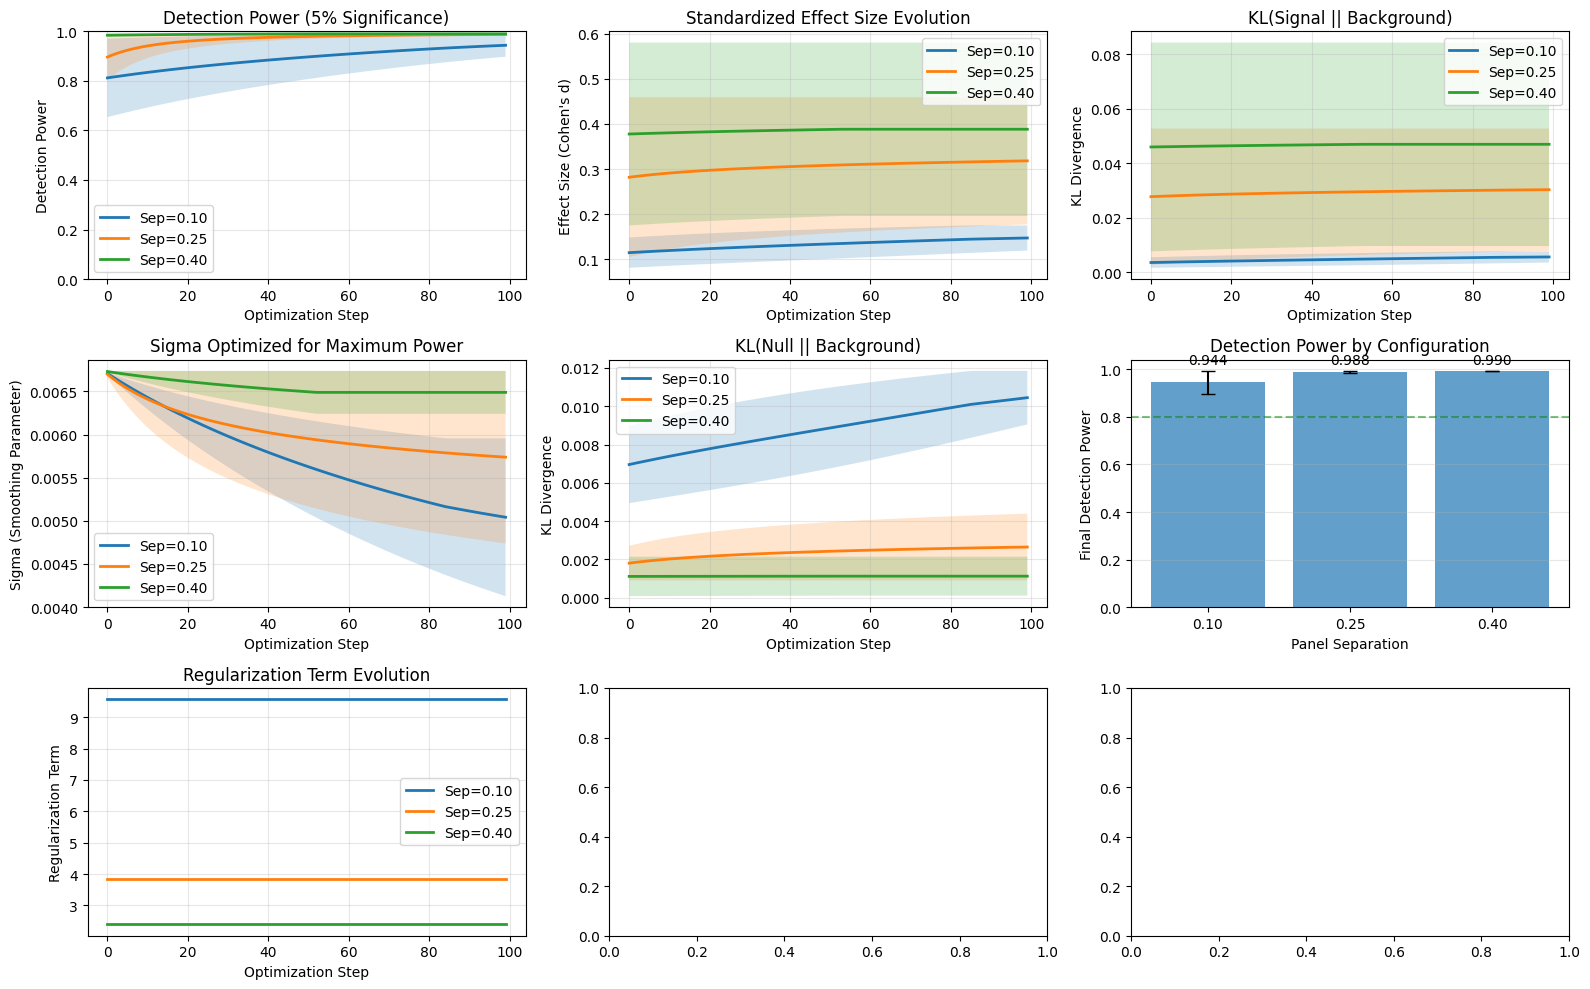

In [13]:
plot_detection_power_analysis(all_histories, resolutions, panel_seps,)